# Paper Source

N. Ali and D. Thue, “Signals of Struggle: Detecting Player Difficulties Using Machine Learning,” in *Proc. Twenty-First AAAI Conference on Artificial Intelligence and Interactive Digital Entertainment (AIIDE)*, vol. 21, no. 1, 2025, pp. 175–185, doi: 10.1609/aiide.v21i1.36821.


# Data Source

https://drive.google.com/drive/folders/1CNq_1D8xMNZG5ueAZQRoAITVfvyiwhV-

# Abstract

The conference paper investigated a system to detect player's struggle moments and its type using their playlogs. 12 participants play Terraria and work on three quests: gathering, combat, crafting in 10 min for each. They then annotate struggle moments and its struggle type carefully with the researchers. The propsoed system utilized separate Random Forest models for each quest and task, feeding many factors such as items user held, control binding used, player coordinates, tile at positon, and so on. The struggle moment detection performance was relatively stable while the struggle type detection performance was unstable. The study provide the participants' playlog information publicly. The authors stated that incorporating time-aware machine learning models is one possible future work. This final project aims to investiagte the best model that can handle the tasks beyond their research content.


# Goal of the study
determine the best model that can
- identifies the player's struggle momoments and the type of struggle: "Performance" or "Cognitive" for struggle moments

# Import Data

In [138]:
import os
import sys
import re
import warnings

import pandas as pd
import numpy as np
import seaborn as sns

from IPython.display import display, HTML, Markdown
from joblib import dump, load

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
Input,
LSTM,
Dense,
Flatten,
TimeDistributed
)

from itertools import combinations
from scipy.stats import ttest_rel

warnings.simplefilter(action='ignore', category=pd.errors.DtypeWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

### Note

#### Target Columns

1. `Struggled`
- Represents whether the player feels struggle at the Unix time.
- Values are `True` / `False`.

2. `Type`
- Specifies the struggle type that the player experienced.
- Values are `Performance` / `Cognitive`.



In [2]:
RANDOM_SEED = 42

In [3]:
total_participants = 12
ratio_train_test = 0.75
no_train = int(12*ratio_train_test)

print("Number of participants")
print(f"Training set\t: {no_train} people")
print(f"Test set\t: {total_participants - no_train} people")

Number of participants
Training set	: 9 people
Test set	: 3 people


In [4]:
def prepare_set(no_train, total_participants=12):
    folders = [["Q1", "MITDMQuest", "gather"],["Q2", "MITDMQuestCombat", "combat"],["Q3", "MITDMQuestCraft", "craft"]]
    dfs = []
    for folder in folders:
        for pid in range(10, 10+total_participants):
            df = pd.read_csv(f"./Training{folder[0]}/P{pid}_{folder[1]}.csv")
            df["Participant Id"] = f"P{pid}"
            df["Quest"] = f"{folder[2]}"

            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df['Row Index'] = df.index
    
    return df

In [5]:
df = prepare_set(no_train)

# Preprocessing

**The goal is to clean the data and decribe each column**

In [6]:
df

,Quest Started,Quest Completed,X,Y,Tile at Location,Control Binding Used,Item Held By Player,Current Health,Number Of Times Died,Chatting With NPC,Player Hitting Enemy,Enemies Killed,Using MineCart,UI Interaction,Hanging Fireblossom,Hanging Waterleaf,Hanging Moonglow,Hanging Daybloom,Copper Shortsword,Wooden Yoyo,Spear,Copper Bow,Boomstick,Wand of Sparking,Copper Axe,Copper Pickaxe,Wood,Stone Block,Dirt Block,Lead Ore,Silver Ore,Cobweb,Work Bench,Metal Fishing Rod,Magic Mirror,Torch,Struggled,Mechanic,Type,Severity,Expected,Participant Id,Quest,Row Index
0,False,False,33614.0,4006.0,Grass,NaN,Torch,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,False,NaN,NaN,NaN,NaN,P10,gather,0
1,False,False,33614.0,4006.0,Grass,NaN,Torch,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,False,NaN,NaN,NaN,NaN,P10,gather,1
2,False,False,33614.0,4006.0,Grass,NaN,Torch,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,False,NaN,NaN,NaN,NaN,P10,gather,2
3,False,False,33614.0,4006.0,Grass,NaN,Torch,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,False,NaN,NaN,NaN,NaN,P10,gather,3
4,False,False,33614.0,4006.0,Grass,NaN,Torch,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,False,NaN,NaN,NaN,NaN,P10,gather,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
896506,True,False,4988.0,4806.0,Stone,MouseLeft,Copper Pickaxe,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,1,1,168,52,16,42,0,0,0,0,1,6,True,Pickaxe,Cognitive,Moderate,True,P21,craft,896506
896507,True,False,4988.0,4806.0,Stone,MouseLeft,Copper Pickaxe,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,1,1,168,52,16,42,0,0,0,0,1,6,True,Pickaxe,Cognitive,Moderate,True,P21,craft,896507
896508,True,False,4988.0,4806.0,Stone,MouseLeft,Copper Pickaxe,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,1,1,168,52,16,42,0,0,0,0,1,6,True,Pickaxe,Cognitive,Moderate,True,P21,craft,896508
896509,True,False,4988.0,4806.0,Stone,MouseLeft,Copper Pickaxe,100 / 100,0,-1,False,0 / 0,False,Closed inventory,0,0,0,0,0,0,0,0,0,0,1,1,168,52,16,42,0,0,0,0,1,6,True,Pickaxe,Cognitive,Moderate,True,P21,craft,896509


In [7]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896511 entries, 0 to 896510
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Quest Started         896511 non-null  object 
 1   Quest Completed       896511 non-null  object 
 2   X                     896511 non-null  float64
 3   Y                     896511 non-null  float64
 4   Tile at Location      710765 non-null  object 
 5   Control Binding Used  478943 non-null  object 
 6   Item Held By Player   885260 non-null  object 
 7   Current Health        896511 non-null  object 
 8   Number Of Times Died  896511 non-null  int64  
 9   Chatting With NPC     896511 non-null  int64  
 10  Player Hitting Enemy  896511 non-null  object 
 11  Enemies Killed        896511 non-null  object 
 12  Using MineCart        896511 non-null  object 
 13  UI Interaction        896511 non-null  object 
 14  Hanging Fireblossom   896511 non-null  int64  
 15  

### Findings
`Quest Started`, `Quest Completed`, and `Struggled` columns should have `Bool` types by looking at some samples in the dataFrame.

However, `object` data type is defined here.

It is suspicious that some data have different data types.

for example, `rows positioned at 685107` show all `zeros`.

---
##### **Let's investigate if there are data samples filled with zeros**
---

In [8]:
def extract_zeros_df(df):
    obj_cols = df.select_dtypes(include="object").columns.tolist()
    max_len = max(len(c) for c in obj_cols)
    
    print("Number of zero values in each object column are ")
    
    excluded_cols = []
    
    for c in obj_cols:
        mask = df[
            df[c].notna() &
            (df[c].map(type) != bool) &
            df[c].isin([0, 0.0, "0"])
        ]
    
        if len(mask) == 0:
            excluded_cols.append(c)
    
        print(f"{c:<{max_len}} : {len(mask)}")

    # since python treats False, NaN, 0, and 0.0 as the same value, here try to extract them except False and NaN
    zero_like_mask = (df.loc[:, (~df.columns.isin(excluded_cols) & df.columns.isin(obj_cols))]
        .apply(lambda c: c.notna() & (c.map(type) != bool) & c.isin([0, 0.0, "0"]))
        .all(axis=1))
    
    excluded_cols_text = ", ".join(excluded_cols)

    print(f"\n{len(df[zero_like_mask])} rows are filled with all zero values for object-type columns except for {excluded_cols_text} columns.")
    display(df[zero_like_mask])

    return df[zero_like_mask]

In [9]:
zero_like_df = extract_zeros_df(df)

Number of zero values in each object column are 
Quest Started        : 135
Quest Completed      : 135
Tile at Location     : 135
Control Binding Used : 135
Item Held By Player  : 3100
Current Health       : 135
Player Hitting Enemy : 135
Enemies Killed       : 135
Using MineCart       : 135
UI Interaction       : 135
Struggled            : 135
Mechanic             : 135
Type                 : 135
Severity             : 135
Expected             : 135
Participant Id       : 0
Quest                : 0

135 rows are filled with all zero values for object-type columns except for Participant Id, Quest columns.


,Quest Started,Quest Completed,X,Y,Tile at Location,Control Binding Used,Item Held By Player,Current Health,Number Of Times Died,Chatting With NPC,Player Hitting Enemy,Enemies Killed,Using MineCart,UI Interaction,Hanging Fireblossom,Hanging Waterleaf,Hanging Moonglow,Hanging Daybloom,Copper Shortsword,Wooden Yoyo,Spear,Copper Bow,Boomstick,Wand of Sparking,Copper Axe,Copper Pickaxe,Wood,Stone Block,Dirt Block,Lead Ore,Silver Ore,Cobweb,Work Bench,Metal Fishing Rod,Magic Mirror,Torch,Struggled,Mechanic,Type,Severity,Expected,Participant Id,Quest,Row Index
319693,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P10,combat,319693
319935,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P10,combat,319935
322817,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P10,combat,322817
323179,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P10,combat,323179
324381,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P10,combat,324381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879822,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P21,craft,879822
881924,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P21,craft,881924
883006,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P21,craft,883006
885408,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,P21,craft,885408


### Findings

Some data samples are filled with zeros, which means no information is recorded.

These zero-filled data do not provide any insight and cause mixing data types.

Each data is recorded per second, and `Row Index` column keeps the order information.

Therefore, it is safe to remove these zero-filled rows.

`Item Held By Player` column have many zero values.

These cells are to be considered `null` since this column represents item names. 

---

##### **Let's remove these data**

##### **Let's fill null in cells with zero for `Item Held By Player` column**

---

In [10]:
df = df[~df["Row Index"].isin(zero_like_df["Row Index"])]

The mixing-type values are successfully removed.

In [11]:
df = df.copy()
c = "Item Held By Player"

df.loc[df[c].notna() & (df[c].map(type) != bool) & df[c].isin([0, 0.0, "0"]),c] = pd.NA

df_nan = df[df[c].isna()]
len(df_nan)

14216

---

##### **Let's unify the data type for `Quest Started`, `Quest Completed`, and `Struggled` columns as `boolean`**

---

In [12]:
df = df.copy()
df["Quest Started"] = df["Quest Started"].astype(bool)
df["Quest Completed"] = df["Quest Completed"].astype(bool)
df["Struggled"] = df["Struggled"].astype(bool)

### Findings

Recording works before a quest starts and after a quest ends.

Therefore,
- `trimming` is requried to only keep the experiment time.
  
---

##### **Let's trim the quest time**

---

In [13]:
pid_num = df["Participant Id"].str.extract(r"P(\d+)").astype(int)[0]

# filter out the test set (only use 9 participants' data)
df_filtered = df[(pid_num >= 10) & (pid_num <= 10 + (no_train -1))]

df_sc = df_filtered[["Quest Started", "Quest Completed", "Struggled"]]
df_struggle = df_sc[df_sc["Struggled"] == True]

print("struggle moments vs quest status")
pd.crosstab(
    df_struggle["Quest Started"],
    df_struggle["Quest Completed"],
    rownames=["Quest Started"],
    colnames=["Quest Completed"]
)

struggle moments vs quest status


Quest Completed,False,True
Quest Started,,
False,8886,0
True,49404,365789


In [14]:
ft = len(df_sc[(df_sc["Quest Started"] == False) & (df_sc["Quest Completed"] == True)])

if ft == 0:
    print("No data sample is captured before quest starts and after quest completed")
else:
    print(f"{ft} data samples are captured before quest starts and after quest completed")

No data sample is captured before quest starts and after quest completed


### Findings

It was assumed that struggles occur only in quest working time. However, some struggles occur even outside the time working on quests.

Trimming should not be performed because the objective of the study is to identify the player's struggle moments and types from playlogs, not only when the player is working on specific quests.

---

**Let's not to perform a trimming**

**Let's find null values**


---


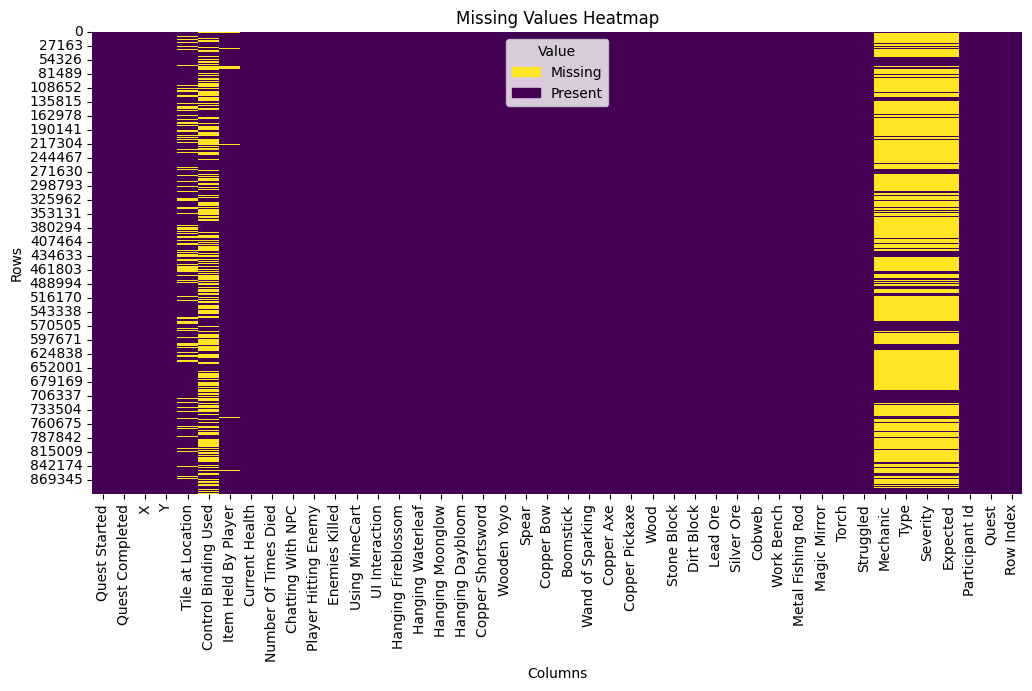

In [15]:
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.pyplot as plt

null_mask = df.isna()

plt.figure(figsize=(12, 6))
ax = sns.heatmap(null_mask, cbar=False, cmap="viridis")

ax.set_title("Missing Values Heatmap")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")

missing_patch = mpatches.Patch(
    color=plt.cm.viridis(1.0), label="Missing"
)
present_patch = mpatches.Patch(
    color=plt.cm.viridis(0.0), label="Present"
)

ax.legend(
    handles=[missing_patch, present_patch],
    title="Value",
    loc="upper center"
)

plt.show()


### Findings

There are null values in `Tile at Location`, `Control Binding Used`, `Item Held by Player`,`Mechanic`, `Type`, `Severity`, and `Expected` columns.

Null values in `Mechanic`, `Type`, `Severity`, and `Expected` columns indicate no struggles at the unix times because they represent detail status when struggle.

Null values in `Tile at Location` indicate that there is no title at the player position, such when jumping.

Null values in `Control Binding Used` indicate no binding is used.

Null values in `Item Held By Player` indicate no item is held.

Therefore, all null values are as expected, and there is no unexpected data lacking.

---

Next step is

##### **Let's list unique elements in each object-type column and find the direction for pre-processing**


---

In [16]:
ITEMS_PER_LINE = 5
COL_WIDTH = 24

BOLD = "\033[1m"
RESET = "\033[0m"

str_cols = df.select_dtypes(include="object").columns.tolist()

for c in str_cols:
    values = sorted(df[c].dropna().apply(str).unique())

    print(f"{BOLD}{c}{RESET}")
    for i, v in enumerate(values, 1):
        print(f"{v:<{COL_WIDTH}}", end="")
        if i % ITEMS_PER_LINE == 0:
            print()
    print("\n")

Tile at Location
ChineseLanterns         ClayBlock               Cobweb                  Containers              Copper                  
Dirt                    DirtiestBlock           DyePlants               FakeContainers          Grass                   
HardenedSand            Hive                    HoneyBlock              ImmatureHerbs           Iron                    
Jackolanterns           LargePiles              LargePiles2             Lead                    MatureHerbs             
MinecartTrack           Mud                     Painting2X3             Plants                  Plants2                 
Platforms               Platinum                Pots                    PressurePlates          Ruby                    
Sand                    Saplings                Signs                   SmallPiles              Stalactite              
Statues                 Stone                   Sunflower               Tombstones              Torches                 
Traps          

### Findings

All object-type classes have categorical values, except `Current Health` and `Enemies Killed` columns have numerical values, and `Using MineCart` and `Expected` columns have boolean values, represetned as string.

Here are the directions for preprocessing and feature-engineering for each object-type column.

---
#### **data already clean and well-categorized**


- `UI Interaction`
- `Mechanic`
- `Type`
- `Severity`
- `Participant Id`
- `Quest`

---

#### **Pre-processing: Convert columns into Boolean type**

- `Expected`
- `Using MineCart`

---

#### **Feature-engineering: Separate into Boolean and Object columns**

those listing columns mix boolean and object names in a single column. Therefore, create independent columns that represent each.

The reason for the separation is that the boolean column is first used as an indicator variable to examine its correlation with the target columns, Struggled and Type. If a correlation is observed, the correlation between the specific information and the target variables is then analyzed.

- `Tile at Location` → `Is Tile at Location`, `Tile Item`

- `Control Binding Used` → `Is Control Binding Used`, `Control Binding`

- `Item Held By Player` → `Is Item Held By Player`, `Holding Item`

- `Player Hitting Enemy` → `Is Hitting Enemy`, `Enemy Name`, `Hitting Damage`

---


#### **Feature-engineering: Convert it to a float, representing the ratio of the current value to the maximum value**

Rather than directly using raw numeric values, the values are normalized for the machine-learning models.

- `Current Health`
- `Enemies Killed`

---

#### **Pre-processing: `Control Binding` columns have some inappropriate values**

These listing values must be in `Holding Item` but currently in `Control Binding`.

- None Item Held By Player: Boomstick
- None Item Held By Player: Copper Axe 
- None Item Held By Player: Copper Bow
- None Item Held By Player: Copper Pickaxe
- None Item Held By Player: Copper Shortsword
- None Item Held By Player: Magic Mirror
- None Item Held By Player: Spear
- None Item Held By Player: Torch
- None Item Held By Player: Wand of Sparking
- None Item Held By Player: Wood
- None Item Held By Player: Wooden Yoyo

In addition, "None Item Held By Player: " is not necessary.

---

#### **Let's perform preprocessing for `Expected`, `Using MineCart`, and `Control Binding` columns and feature-engineering for `Player Hitting Enemy`, `Tile at Location`, `Control Binding Used`, `Item Held By Player`, `Current Health`, and `Enemies Killed` columns**

---

In [17]:
df["Expected"] = df["Expected"].map({"True": True, "False": False})
df["Expected"] = df["Expected"].astype("boolean")
df["Using MineCart"] = df["Using MineCart"].fillna(False).astype(bool)

In [18]:
def create_indicator_column(df, c, info_c):
    if not info_c in df.columns:
        ind_c = f"Is {c}"
        df[ind_c] = df[c].notna()
        df.rename(columns={c: info_c}, inplace=True)
        df[info_c] = df[info_c]

create_indicator_column(df, "Tile at Location", "Tile Item")
create_indicator_column(df, "Control Binding Used", "Control Binding")
create_indicator_column(df, "Item Held By Player", "Holding Item")

In [19]:
# investigate "Holding Item" contains null when labeling errors happen in "Control Binding"
label_error_df = df[df["Control Binding"].str.contains("None Item", na=False)]
label_error_df["Holding Item"].isna().all()

True

In [20]:
mask = df["Row Index"].isin(label_error_df["Row Index"])

df.loc[mask, "Control Binding"] = (
    df.loc[mask, "Control Binding"]
    .str.extract(r"^None Item Held By Player:\s*(.+)$")
)

df.loc[mask, ["Holding Item", "Control Binding"]] = (
    df.loc[mask, ["Control Binding", "Holding Item"]].values
)

In [21]:
df = df.copy()

c = "Player Hitting Enemy"

if (c in list(df.columns)):
    df["Is Hitting Enemy"] = df[c].astype(str).str.extract(r"^(True)").fillna(False).astype(bool)
    df["Enemy Name"]   = df[c].astype(str).str.extract(r"Target NPC: (\w+)")
    df["Hitting Damage"] = df[c].astype(str).str.extract(r"Damage = (\d+)").astype(float)
    df.drop(columns=[c], inplace=True)

In [22]:
def assign_ratio(df, c):
    if not pd.api.types.is_float_dtype(df[c]):
        tmp = df[c].str.extract(r"(\d+)\s*/\s*(\d+)")
        num = tmp[0].astype(float)
        den = tmp[1].astype(float)
        df[c] = num.div(den).fillna(0)
        df[c] = df[c].astype(float)

assign_ratio(df, "Current Health")
assign_ratio(df, "Enemies Killed")

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 896376 entries, 0 to 896509
Data columns (total 49 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Quest Started            896376 non-null  bool   
 1   Quest Completed          896376 non-null  bool   
 2   X                        896376 non-null  float64
 3   Y                        896376 non-null  float64
 4   Tile Item                710630 non-null  object 
 5   Control Binding          477641 non-null  object 
 6   Holding Item             882160 non-null  object 
 7   Current Health           896376 non-null  float64
 8   Number Of Times Died     896376 non-null  int64  
 9   Chatting With NPC        896376 non-null  int64  
 10  Enemies Killed           896376 non-null  float64
 11  Using MineCart           896376 non-null  bool   
 12  UI Interaction           896376 non-null  object 
 13  Hanging Fireblossom      896376 non-null  int64  
 14  Hanging W

### Findings

Now all the columns represent data clearly.

Object type can contain mixed data types and are unsecure. 

---

##### **Let's convert object-type columns into string data type**

---

In [24]:
obj_cols = df.select_dtypes(include="object").columns.tolist()

for c in obj_cols:
    df[c] = df[c].astype("string")

In [25]:
df.dtypes

Quest Started                        bool
Quest Completed                      bool
X                                 float64
Y                                 float64
Tile Item                  string[python]
Control Binding            string[python]
Holding Item               string[python]
Current Health                    float64
Number Of Times Died                int64
Chatting With NPC                   int64
Enemies Killed                    float64
Using MineCart                       bool
UI Interaction             string[python]
Hanging Fireblossom                 int64
Hanging Waterleaf                   int64
Hanging Moonglow                    int64
Hanging Daybloom                    int64
Copper Shortsword                   int64
Wooden Yoyo                         int64
Spear                               int64
Copper Bow                          int64
Boomstick                           int64
Wand of Sparking                    int64
Copper Axe                        

### Findings

Now the data cleaning is completed.

Each string class holds categorical values.

---

##### **Let's look at cateogies in string classes of the cleaned data frame**

---


In [26]:
ITEMS_PER_LINE = 5
COL_WIDTH = 24

BOLD = "\033[1m"
RESET = "\033[0m"

str_cols = df.select_dtypes(include="string").columns.tolist()

for c in str_cols:
    values = sorted(df[c].dropna().apply(str).unique())

    print(f"{BOLD}{c}{RESET}")
    for i, v in enumerate(values, 1):
        print(f"{v:<{COL_WIDTH}}", end="")
        if i % ITEMS_PER_LINE == 0:
            print()
    print("\n")

Tile Item
ChineseLanterns         ClayBlock               Cobweb                  Containers              Copper                  
Dirt                    DirtiestBlock           DyePlants               FakeContainers          Grass                   
HardenedSand            Hive                    HoneyBlock              ImmatureHerbs           Iron                    
Jackolanterns           LargePiles              LargePiles2             Lead                    MatureHerbs             
MinecartTrack           Mud                     Painting2X3             Plants                  Plants2                 
Platforms               Platinum                Pots                    PressurePlates          Ruby                    
Sand                    Saplings                Signs                   SmallPiles              Stalactite              
Statues                 Stone                   Sunflower               Tombstones              Torches                 
Traps                 

### Summary

Let's describe each column

####  Data Description

Each row is recorded per second


| Column Name | Data Type | Description |
|------------|----------|-------------|
| Row Index | int64 | index number|
| Participant Id | string | Participant unique ID|
| Quest | string | Quest name|
| Quest Started | bool | Whether a quest has been started|
| Quest Completed | bool | Whether a quest has been completed|
| X | float64 | The player's x-coordinate position|
| Y | float64 | The player's y-coordinate position|
| Is Tile at Location (**Feature-engineered**) | bool | Whether the tile is at the player position|
| Tile Item | string | Tile Item at the player position|
| Is Control Binding Used (**Feature-engineered**) | bool | Whether a control binding is used |
| Control Binding | string | Control binding used|
| Is Item Held By Player (**Feature-engineered**) | bool | Whether the player holds an item|
| Holding Item | string | Holding Item|
| Is Hitting Enemy (**Feature-engineered**) | bool | Whether the player is hitting an enemy|
| Enemy Name | string | What enemy is hit by the player |
| Hitting Damage | float64 | How many damages are hit by the player|
| Current Health (**Feature-engineered**) | float64 | The ratio of the current health to the maximum health|
| Number Of Times Died | int64 | The number of times died |
| Chatting With NPC | int64 | The number of times the player chat with NPC|
| Enemies Killed (**Feature-engineered**) | float64 | The ratio of the number of enemies killed to the total number to be killed|
| Using MineCart | bool | Whether the player is using minecart |
| UI Interaction | string | What action on UI is taken by the player |
| **Item Related Columns**<br>Hanging Fireblossom, Hanging Waterleaf, Hanging Moonglow, Hanging Daybloom,<br>Copper Shortsword, Wooden Yoyo, Spear, Copper Bow, Boomstick, Wand of Sparking,<br>Copper Axe, Copper Pickaxe, Wood, Stone Block, Dirt Block, Lead Ore, Silver Ore,<br>Cobweb, Work Bench, Metal Fishing Rod, Magic Mirror, Torch | int64 | Item status (Inverntory, planting)|
| Struggled (**Target column**) | bool | Whether the player struggles |
| Mechanic | string | The factor to make the player struggle |
| Type (**Target column**) | string | The struggle type|
| Severity | string | The severity of the struggle|
| Expected | boolean | Whether the struggle was expected|





# Data Understanding

**The goals are**

- **to provide a descriptive study**

- **to decide columns for the model along with feature-enginnering new columns**


### Assumption

- Since the world in Terraria is dynamically generated, the player's `X` and `Y` coordinates are assumed to be independent of struggle. However, whether the player is moving or staying can be a factor.


##### **Let's feature-engineer columns `dX` `dY` that represent the movement difference from the previous record**

In [27]:
if not "dX" in df.columns:
    df["dX"] = df["X"].diff().fillna(0)
    df.drop(columns="X", inplace=True)

if not "dY" in df.columns:
    df["dY"] = df["Y"].diff().fillna(0)
    df.drop(columns="Y", inplace=True)

##### **here starts a descriptive study. Therefore, let's separate df into training and test sets**

In [28]:
# 9 people for training
tr = df[(pid_num >= 10) & (pid_num <= 10 + (no_train -1))]

# three people for testing
te = df[pid_num >= (10 + no_train)]

##### **Let's show descriptive information for each column for each quest**

In [29]:
int_tr = tr.select_dtypes(include="int").columns
int_tr = tr[["Quest", *int_tr]]
grouped = int_tr.groupby(["Quest"])

In [30]:
print("sum for each int column")
display(grouped.sum())

sum for each int column


,Number Of Times Died,Chatting With NPC,Hanging Fireblossom,Hanging Waterleaf,Hanging Moonglow,Hanging Daybloom,Copper Shortsword,Wooden Yoyo,Spear,Copper Bow,Boomstick,Wand of Sparking,Copper Axe,Copper Pickaxe,Wood,Stone Block,Dirt Block,Lead Ore,Silver Ore,Cobweb,Work Bench,Metal Fishing Rod,Magic Mirror,Torch,Row Index
Quest,,,,,,,,,,,,,,,,,,,,,,,,,
combat,1305699,0,0,0,0,0,170498,170498,170498,170498,170498,170498,0,0,71,0,0,0,0,13,0,0,0,55,68758717435
craft,0,-268696,0,0,0,0,0,0,0,0,0,0,274833,274933,5727089,1556945,910712,134796,0,5210448,96894,0,274933,2446225,185345832026
gather,230000,-231596,57436,13562,9055,44856,0,0,0,0,0,0,0,0,0,0,0,0,0,841880,0,0,239573,234864,28697491378


In [31]:
print("mean for each int column")
grouped.mean()

mean for each int column


,Number Of Times Died,Chatting With NPC,Hanging Fireblossom,Hanging Waterleaf,Hanging Moonglow,Hanging Daybloom,Copper Shortsword,Wooden Yoyo,Spear,Copper Bow,Boomstick,Wand of Sparking,Copper Axe,Copper Pickaxe,Wood,Stone Block,Dirt Block,Lead Ore,Silver Ore,Cobweb,Work Bench,Metal Fishing Rod,Magic Mirror,Torch,Row Index
Quest,,,,,,,,,,,,,,,,,,,,,,,,,
combat,7.658148,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.0,0.000416,0.000000,0.000000,0.000000,0.0,0.000076,0.000000,0.0,0.0,0.000323,403281.665679
craft,0.000000,-0.977314,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.999636,1.0,20.830853,5.662998,3.312487,0.490287,0.0,18.951701,0.352428,0.0,1.0,8.897531,674149.090964
gather,0.960041,-0.966703,0.239743,0.056609,0.037796,0.187233,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,3.514085,0.000000,0.0,1.0,0.980344,119786.000000


In [32]:
print("standard diviation for each int column")
grouped.std()

standard diviation for each int column


,Number Of Times Died,Chatting With NPC,Hanging Fireblossom,Hanging Waterleaf,Hanging Moonglow,Hanging Daybloom,Copper Shortsword,Wooden Yoyo,Spear,Copper Bow,Boomstick,Wand of Sparking,Copper Axe,Copper Pickaxe,Wood,Stone Block,Dirt Block,Lead Ore,Silver Ore,Cobweb,Work Bench,Metal Fishing Rod,Magic Mirror,Torch,Row Index
Quest,,,,,,,,,,,,,,,,,,,,,,,,,
combat,5.676658,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.073815,0.000000,0.000000,0.000000,0.0,0.008732,0.000000,0.0,0.0,0.071556,49230.999900
craft,0.000000,0.148899,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.019068,0.0,25.483172,12.892241,11.357708,1.064963,0.0,18.110318,0.764374,0.0,0.0,2.108921,79378.075659
gather,1.075515,0.179411,0.426928,0.231095,0.190704,0.390099,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,6.065946,0.000000,0.0,0.0,0.138815,69158.912358


In [33]:
print("variance for each int column")
grouped.var()

variance for each int column


,Number Of Times Died,Chatting With NPC,Hanging Fireblossom,Hanging Waterleaf,Hanging Moonglow,Hanging Daybloom,Copper Shortsword,Wooden Yoyo,Spear,Copper Bow,Boomstick,Wand of Sparking,Copper Axe,Copper Pickaxe,Wood,Stone Block,Dirt Block,Lead Ore,Silver Ore,Cobweb,Work Bench,Metal Fishing Rod,Magic Mirror,Torch,Row Index
Quest,,,,,,,,,,,,,,,,,,,,,,,,,
combat,32.224451,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.005449,0.000000,0.00000,0.000000,0.0,0.000076,0.000000,0.0,0.0,0.005120,2.423691e+09
craft,0.000000,0.022171,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000364,0.0,649.392031,166.209887,128.99752,1.134147,0.0,327.983602,0.584268,0.0,0.0,4.447548,6.300879e+09
gather,1.156731,0.032188,0.182267,0.053405,0.036368,0.152178,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.0,36.795701,0.000000,0.0,0.0,0.019270,4.782955e+09


### Finding

Some columns show standard deviation with 0, which means all data has the identical value and do not provide any insight.

The reason that `Chatting With NPC` column has negative value is because no chatting represents -1, otherwise 0.

##### **Let's investigate columns filled with an identical value.**


In [34]:
grouped_tr = tr.groupby("Quest")
one_value_by_quest = (
    grouped_tr
    .nunique()
    .eq(1)
    .apply(lambda row: row.index[row].tolist(), axis=1)
)

for quest, cols in one_value_by_quest.items():
    print(f"{quest}:")
    for i, c in enumerate(cols, 1):
        dtype = grouped_tr.get_group(quest)[c].dtype
        print(f"{c:<25} {str(dtype):<25}  ", end="")
        if i % ITEMS_PER_LINE == 0:
            print()
    print("\n")

combat:
Quest Started             bool                       Chatting With NPC         int64                      UI Interaction            string                     Hanging Fireblossom       int64                      Hanging Waterleaf         int64                      
Hanging Moonglow          int64                      Hanging Daybloom          int64                      Copper Shortsword         int64                      Wooden Yoyo               int64                      Spear                     int64                      
Copper Bow                int64                      Boomstick                 int64                      Wand of Sparking          int64                      Copper Axe                int64                      Copper Pickaxe            int64                      
Stone Block               int64                      Dirt Block                int64                      Lead Ore                  int64                      Silver Ore                int64    

### Findings 

The above list indicates columns for each quest, filled with an identical value.

# Experimental Setup

**The goals are**
- to label **string** and **boolean** columns
- to split the current training set into train and validation sets using k-fold cross validation
- to create windows in the sets
- to prepare the models and metrices

##### **Let's label data in each string and boolean column using LabelEncorder**

In [35]:
EXCLUDE_COLS = [
    "Participant Id",
    "Quest",
]

encode_cols = (
    tr
    .select_dtypes(include=["string", "bool"])
    .columns
    .difference(EXCLUDE_COLS)
)


for col in encode_cols:
    le = LabelEncoder()
    tr[col] = le.fit_transform(tr[col].astype(str))

/var/folders/9l/hq58x6qs0x73q9vhsy6dk21w0000gn/T/ipykernel_19569/2041157509.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tr[col] = le.fit_transform(tr[col].astype(str))
/var/folders/9l/hq58x6qs0x73q9vhsy6dk21w0000gn/T/ipykernel_19569/2041157509.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tr[col] = le.fit_transform(tr[col].astype(str))
/var/folders/9l/hq58x6qs0x73q9vhsy6dk21w0000gn/T/ipykernel_19569/2041157509.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

##### **Let's separate data frame for each quest and remove unnecessary columns**

In [36]:
grouped_tr = tr.groupby("Quest")
grouped_te = te.groupby("Quest")

In [37]:
tr_quest = {
    quest: g.copy()
    for quest, g in grouped_tr
}

te_quest = {
    quest: g.copy()
    for quest, g in grouped_te
}

In [38]:
for quest, cols in one_value_by_quest.items():
    tr_quest[quest].drop(columns=list(cols), inplace=True)
    te_quest[quest].drop(columns=list(cols), inplace=True)

##### **Let's check what columns will be fed into the model for each quest**

In [39]:
EXCLUDE_COLS = [
    "Participant Id",
    "Quest",
    "Row Index"
]


for quest, cols in tr_quest.items():
    print(f"{quest}:")
    diff_i = 0
    for i, c in enumerate(cols, 1):
        if c in EXCLUDE_COLS:
            diff_i += 1
            continue
        print(f"{c:<30}", end="")
        if (i-diff_i) % ITEMS_PER_LINE == 0:
            print()
    print("\n")

combat:
Quest Completed               Tile Item                     Control Binding               Holding Item                  Current Health                
Number Of Times Died          Enemies Killed                Using MineCart                Wood                          Cobweb                        
Torch                         Struggled                     Mechanic                      Type                          Severity                      
Expected                      Is Tile at Location           Is Control Binding Used       Is Item Held By Player        Is Hitting Enemy              
Enemy Name                    Hitting Damage                dX                            dY                            

craft:
Quest Started                 Quest Completed               Tile Item                     Control Binding               Holding Item                  
Chatting With NPC             Using MineCart                UI Interaction                Copper Axe        

##### **Let's check how the labeled training set looks like**

In [40]:
tr_quest["combat"].head()

,Quest Completed,Tile Item,Control Binding,Holding Item,Current Health,Number Of Times Died,Enemies Killed,Using MineCart,Wood,Cobweb,Torch,Struggled,Mechanic,Type,Severity,Expected,Participant Id,Quest,Row Index,Is Tile at Location,Is Control Binding Used,Is Item Held By Player,Is Hitting Enemy,Enemy Name,Hitting Damage,dX,dY
318012,1,9,0,7,1.0,0,0.0,1,0,0,0,1,0,0,0,0,P10,combat,318012,1,0,1,0,0,NaN,-27986.0,-2912.0
318013,1,9,0,7,1.0,0,0.0,1,0,0,0,1,0,0,0,0,P10,combat,318013,1,0,1,0,0,NaN,0.0,0.0
318014,1,9,0,7,1.0,0,0.0,1,0,0,0,1,0,0,0,0,P10,combat,318014,1,0,1,0,0,NaN,0.0,0.0
318015,1,9,0,7,1.0,0,0.0,1,0,0,0,1,0,0,0,0,P10,combat,318015,1,0,1,0,0,NaN,0.0,0.0
318016,1,9,0,7,1.0,0,0.0,1,0,0,0,1,0,0,0,0,P10,combat,318016,1,0,1,0,0,NaN,0.0,0.0


##### **Let's create train/validation sets using k-fold cross validation for each quest**

##### **Let's prepare models**

- Random Forest
- LSTM

Window size: 10

##### **LSTM model for struggle detection**

In [232]:
def struggle_LSTM_model(window_X, features_X, features_Y, n_layers, n_neurons):
    """
    Create a LSTM model for struggle detection
    """    
    
    model = Sequential()
    model.add(Input(shape=(window_X, features_X)))

    for i in range(n_layers):
        model.add(
            LSTM(
                n_neurons,
                return_sequences=True  # needed for stacking
            )
        )

    model.add(TimeDistributed(Dense(features_Y, activation="sigmoid")))
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [233]:
struggle_LSTM_model(10,19,1, 1, 64).summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_41 (LSTM)                  │ (None, 10, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_41             │ (None, 10, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

##### **LSTM model for struggle type detection**

In [234]:
def type_LSTM_model(window_X, features_X, features_Y, n_layers, n_neurons):
    """
    Create a LSTM model for type detection
    """  
    model = Sequential()
    model.add(Input(shape=(window_X, features_X)))

    for i in range(n_layers):
        model.add(
            LSTM(
                n_neurons,
                return_sequences=True  # needed for stacking
            )
        )

    model.add(TimeDistributed(Dense(features_Y, activation="sigmoid")))

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [235]:
type_LSTM_model(10,3,3, 1, 64).summary()

Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_42 (LSTM)                  │ (None, 10, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_42             │ (None, 10, 3)          │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,603 (68.76 KB)

 Trainable params: 17,603 (68.76 KB)

 Non-trainable params: 0 (0.00 B)

##### **Define utility functions**

In [3]:
def check_data_exist(c_name, result_df, fold, quest, target, n_estimators, n_layers, n_neurons):
    """
    check if the result is already obtained
    """
    mask = (
        (result_df["quest"] == quest) &
        (result_df["target"].isin(target)) &  # check multiple targets
        (result_df["classifier"] == c_name) &
        (result_df["n_estimators"] == n_estimators) &
        (result_df["n_layers"] == n_layers) &
        (result_df["n_neurons"] == n_neurons) 
    )
    
    # Check if F1 is already set
    if not result_df.loc[mask, "F1"].isna().all():
        print(f"skip: quest:{quest}, fold: {fold}, classifier: {c_name}")            
        return True

    return False

In [107]:
def make_windows(train_X ,train_Y, c_name, window_size=10):
    """
    split data frame into set of windows
    """
    window_Xs, window_Ys = [], []
    
    # window cannot cross Participant Id
    for pid, g_X in train_X.groupby("Participant Id"):
        g_Y = train_Y.loc[g_X.index]
        
        # sliding window should be within the same participant
        # drop the edge if it is less than the window size
        for i in range(0, len(g_X) - window_size + 1, window_size):
            
            window_X = g_X.iloc[i:i+window_size].drop(columns=["Row Index", "Participant Id", "Quest"]).values
            window_Y = g_Y.iloc[i:i+window_size].values

            if c_name == "Random Forest":
                window_X = window_X.flatten()
                window_Y = window_Y.flatten()
            
            window_Xs.append(window_X)
            window_Ys.append(window_Y)
            
    return np.array(window_Xs), np.array(window_Ys)


In [45]:
def create_train_val(train_X, train_Y, train_idx, val_idx):
    """
    feed input for a quest and define the training and validation set 
    based on index spliting by k-fold cross validation
    """

    train_X, val_X = (train_X.iloc[train_idx], train_X.iloc[val_idx])
    train_Y, val_Y = (train_Y.iloc[train_idx], train_Y.iloc[val_idx])

    return train_X, val_X, train_Y, val_Y

In [292]:
def fit_model(model, result_df, train_X, train_Y, val_X, val_Y, quest, c_name, fold, target, n_estimators, n_layers, n_neurons):
    """
    train and save the given model and 
    calculate and store the f1 score for the validation set
    """
    
    model.fit(train_X, train_Y)
    
    # save the model
    if c_name == "Random Forest":
        dump(model, f"{c_name}_{quest}_{fold}_{n_estimators}.joblib")
    elif c_name == "LSTM":
        model.save(f"{c_name}_{quest}_{fold}_{target[0]}_{n_layers}_{n_neurons}.keras")

    # validate the model
    pred_y = model.predict(val_X)

    if c_name == "Random Forest":
        for i, col in enumerate(target):
            # Calculate the f1 score
            f1_value = f1_score(val_Y[:, i], pred_y[:, i], average='macro')
            # store it
            if (n_layers == None ) and (n_neurons == None):
                result_df.loc[len(result_df)] = [quest, col, c_name, fold, f1_value, n_estimators, n_layers, n_neurons]
            else:
                print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
                print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
                print("n_layers and n_neurons have values")
                print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
                print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")

    elif c_name == "LSTM":
        if target == ["Struggled"]:
            pred_y = (tf.sigmoid(pred_y) > 0.5).numpy().astype(int)
            true_y = val_Y.astype(int)

        elif target == ["Type"]:
            # take the label with the maximum probability
            pred_y = np.argmax(tf.nn.softmax(pred_y, axis=-1).numpy(), axis=-1)
            true_y = np.argmax(val_Y, axis=-1)

        f1_value = f1_score(true_y.reshape(-1), pred_y.reshape(-1), average='macro')
        if  n_estimators == None:
            result_df.loc[len(result_df)] = [quest, target[0], c_name, fold, f1_value, n_estimators, n_layers, n_neurons]   
        else:
                print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
                print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
                print("n_estimators has values")
                print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
                print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")

In [4]:
def train_evaluate(c_name, result_df, fold, quest, train_X, train_Y, train_idx, val_idx, target, n_estimators=None, n_layers=None, n_neurons=None):
    if c_name == "Random Forest":
        n_estimators = n_estimators if n_estimators else 20
    elif c_name == "LSTM":
        n_layers = n_layers if n_layers else 1
        n_neurons = n_neurons if n_neurons else 64
        
    if not check_data_exist(c_name, result_df, fold, quest, target, n_estimators, n_layers, n_neurons):

        train_X, val_X, train_Y, val_Y = create_train_val(train_X, train_Y, train_idx, val_idx)
        
        # make windows for train and val sets
        train_X, train_Y = make_windows(train_X ,train_Y, c_name)
        val_X,   val_Y   = make_windows(val_X, val_Y, c_name)

        if c_name == "Random Forest":
            # make separate models for each target
            model = MultiOutputClassifier(RandomForestClassifier(criterion='entropy', max_features=None,n_estimators=n_estimators, verbose=1, random_state=RANDOM_SEED))

        
        elif c_name == "LSTM":
            _, window_X, features_X = train_X.shape
            
            if (len(target) == 1) & (target == ["Struggled"]):
                # extract the "struggled" column
                train_Y = train_Y[:, :, 0:1]
                val_Y   =   val_Y[:, :, 0:1]
    
                # Define the model
                _, _, features_Y = train_Y.shape
                model = struggle_LSTM_model(window_X, features_X, features_Y, n_layers, n_neurons)
    
            elif (len(target) == 1) & (target == ["Type"]):
                # Extract the "Type" column converting integer label (Nan, performance, cognitive) into one-hot vector
                train_Y = tf.one_hot(train_Y[:, :, 1].astype(int), depth=3)
                val_Y   = tf.one_hot(val_Y[:, :, 1].astype(int), depth=3)
                
                # Define the model
                _, _, features_Y = train_Y.shape
                model = type_LSTM_model(window_X, features_X, features_Y,  n_layers, n_neurons)
            
        # fit the model
        fit_model(model, result_df, train_X, train_Y, val_X, val_Y, quest, c_name, fold, target, n_estimators, n_layers, n_neurons)

In [249]:
def quest_set_iterator(tr_quest, target):
    """
    Each quest requires a separate k-fold cross validation operation
    because each has different data frame.
    This function creates a generator to produce k-fold train/val sets for each quest.
    """
    
    for quest, d in tr_quest.items():
        # define columns for input and output
        train_X = d.drop(columns=["Struggled", "Type", "Mechanic", "Type", "Severity", "Expected"])
        train_Y = d[target]
    
        groups = d["Participant Id"]
        gkf = GroupKFold(n_splits=3)
    
        # split the training set by participant Id (this process is deterministic)
        train_validation_splits = gkf.split(train_X, train_Y, groups)

        yield train_validation_splits, train_X, train_Y, quest

##### **Define a data frame to store the results**

In [293]:
result_df = pd.DataFrame({
    "quest" : pd.Series(dtype="string"),
    "target": pd.Series(dtype="string"),
    "classifier": pd.Series(dtype="string"),
    "Fold": pd.Series(dtype="int"),
    "F1": pd.Series(dtype="float"),
    "n_estimators": pd.Series(dtype="int"),
    "n_layers" : pd.Series(dtype="int"),
    "n_neurons" :pd.Series(dtype="int")
})

##### **Let's train Random Forest and LSTM for each fold for each quest** 

In [294]:
target = ["Struggled", "Type"]

# create folds and training sets for a quest (iterator)
for train_val_splits, train_X, train_Y, quest in quest_set_iterator(tr_quest, target):
    for fold, (train_idx, val_idx) in enumerate(train_val_splits, 1):
        train_evaluate("Random Forest", result_df, fold, quest, train_X, train_Y, train_idx, val_idx, target)
        train_evaluate("LSTM"         , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Struggled"])
        train_evaluate("LSTM"         , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Type"])

[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]

360/360 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.2196 - loss: 3.5012
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.0000e+00 - loss: 9.0192e-06
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]

361/361 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.0770 - loss: 1.2277
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
361/361 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.7s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.7s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    1.7s finished
[Parallel(n_jobs=1)]

...

477/477 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.8012 - loss: 12.7728
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
477/477 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]

485/485 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7951 - loss: 12.6765
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
485/485 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    2.9s finished
[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]

537/537 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7437 - loss: 11.8560
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
537/537 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


### Note
- **Number of estimators for the above Random Forest models are set to 20.**

- **Number of layers and neurons for each layer for the above LSTM models are set to 1 and 64 respectively.**

##### **Let's analyze how the hyperparameter affects the model performance**

Here is the table of models to be trained from now on

| Model         | n_estimators | n_layers | n_neurons |
|--------------|--------------|----------|-----------|
| Random Forest | 50           | –        | –         |
| Random Forest | 100          | –        | –         |
| Random Forest | 200          | –        | –         |
| LSTM          | –            | 2        | 64        |
| LSTM          | –            | 3        | 64        |
| LSTM          | –            | 1        | 128       |
| LSTM          | –            | 2        | 128       |
| LSTM          | –            | 3        | 128       |

In [ ]:
target = ["Struggled", "Type"]

# create folds and training sets for a quest (iterator)
for train_val_splits, train_X, train_Y, quest in quest_set_iterator(tr_quest, target):
    for fold, (train_idx, val_idx) in enumerate(train_val_splits, 1): 
        train_evaluate("Random Forest", result_df, fold, quest, train_X, train_Y, train_idx, val_idx, target, n_estimators=50)
        train_evaluate("Random Forest", result_df, fold, quest, train_X, train_Y, train_idx, val_idx, target, n_estimators=100)
        train_evaluate("Random Forest", result_df, fold, quest, train_X, train_Y, train_idx, val_idx, target, n_estimators=200)

        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Type"], n_layers=2)
        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Type"], n_layers=3)
        train_evaluate("LSTM"           , result_df ,fold, quest, train_X, train_Y, train_idx, val_idx, ["Type"],                  n_neurons=128)
        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Type"], n_layers=2,      n_neurons=128)
        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Type"], n_layers=3,      n_neurons=128)
        
        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Struggled"], n_layers=2)
        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Struggled"], n_layers=3)
        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Struggled"],             n_neurons=128)
        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Struggled"], n_layers=2, n_neurons=128)
        train_evaluate("LSTM"           , result_df, fold, quest, train_X, train_Y, train_idx, val_idx, ["Struggled"], n_layers=3, n_neurons=128)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.8s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    3.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.8s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    3.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.8s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    3.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    3.8s
[Parallel(n_jobs=1)]: 

360/360 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 8.6919e-06 - loss: 9.6469e-06
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.2196 - loss: 3.5012
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.2196 - loss: 3.5012
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.2196 - loss: 3.5012
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
360/360 ━━━━━━

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.1s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    5.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    5.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.0s
[Parallel(n_jobs=1)]: 

361/361 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
361/361 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
361/361 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.0000e+00 - loss: 3.0456e-05
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
361/361 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 8.6693e-06 - loss: 9.4808e-06
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
361/361 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
361/361 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.0770 - loss: 1.2277
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
361/361 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.0770 - loss: 1.2277
173/173 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
361/361 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.0770 - loss: 1.2277
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
361/361 ━━━━━

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.2s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    4.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.2s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    4.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.2s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    4.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.1s
[Parallel(n_jobs=1)]: 

346/346 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.1482 - loss: 2.3634
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.1482 - loss: 2.3634
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.1482 - loss: 2.3634
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
346/346 ━━

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.2s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    5.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.2s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    5.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.1s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.1s
[Parallel(n_jobs=1)]: 

550/550 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
550/550 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
550/550 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
550/550 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07
310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
448/550 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.0000e+00 - loss: 1.1921e-07

### Findings

A large time is requried, and the hyperparameter analysis is decided not to be conducted.

# Results

**The goal of this section is**

- to compare the performance of the trained models using pairwise t-tests

##### **Define pairwise t-test**

In [210]:
def pairwise_t_test(result_df, c_name, alpha=0.05):
    flag = False
    targets = result_df[c_name].unique()
    # for all combinations
    for t1, t2 in combinations(targets, 2):
        f1_t1 = result_df[result_df[c_name] == t1]["F1"]
        f1_t2 = result_df[result_df[c_name] == t2]["F1"]

        # t-test
        t_stat, p_val = ttest_rel(f1_t1, f1_t2)
        
        # if the p-value is less than the critical value
        if p_val < alpha:
            print("------------------------------------------------------------------------------------------")
            print(f"                A significant difference between {c_name}s: {t1} and {t2}                ")
            print("------------------------------------------------------------------------------------------")
            flag = True
    if flag == False:
            print("XXXX---------------------------------------------------------------------------------XXXX")
            print(f"                             No significant difference                                  ")
            print("XXXX---------------------------------------------------------------------------------XXXX")
            

##### **Let's check the average F1-score for each quest**

In [211]:
display(result_df.groupby("quest")["F1"].mean())
pairwise_t_test(result_df, "quest")

quest
combat    0.422036
craft     0.435410
gather    0.360463
Name: F1, dtype: float64

XXXX---------------------------------------------------------------------------------XXXX
                             No significant difference                                  
XXXX---------------------------------------------------------------------------------XXXX


##### **Let's check the average F1-score for each classifier**

In [213]:
display(result_df.groupby("classifier")["F1"].mean())
pairwise_t_test(result_df, "classifier")

classifier
LSTM             0.269399
Random Forest    0.542540
Name: F1, dtype: float64

------------------------------------------------------------------------------------------
                A significant difference between classifiers: Random Forest and LSTM                
------------------------------------------------------------------------------------------


##### **Let's check the average F1-score for each target**

In [214]:
display(result_df.groupby("target")["F1"].mean())
pairwise_t_test(result_df, "target")


target
Struggled    0.508546
Type         0.303393
Name: F1, dtype: float64

------------------------------------------------------------------------------------------
                A significant difference between targets: Struggled and Type                
------------------------------------------------------------------------------------------


##### **Let's check the average score for each classifier, each quest, and each target**

In [120]:
result_df.groupby(["quest", "target", "classifier"])["F1"].mean()

quest   target     classifier   
combat  Struggled  LSTM             0.119412
                   Random Forest    0.921061
        Type       LSTM             0.340861
                   Random Forest    0.306809
craft   Struggled  LSTM             0.145636
                   Random Forest    1.000000
        Type       LSTM             0.278611
                   Random Forest    0.317394
gather  Struggled  LSTM             0.439126
                   Random Forest    0.426042
        Type       LSTM             0.292750
                   Random Forest    0.283934
Name: F1, dtype: float64

##### **Let's investigate the statistical significance between the two models within each quest and target**

In [172]:
results = []
pairwise_tables = []

# model comparison for each quest and target
for (quest, target), g in result_df.groupby(["quest","target"]):
    models = sorted(g["classifier"].unique())
    f1_dict = {m: g[g["classifier"]==m].sort_values("Fold")["F1"].values for m in models}
    mean_dict = {m: round(vals.mean(),4) for m, vals in f1_dict.items()}

    p_val_tbl = pd.DataFrame(index=models, columns=models, dtype=float)
    sig_tbl = pd.DataFrame(index=models, columns=models, dtype=bool)

    # for each combination (pair-wise)
    for m1, m2 in combinations(models,2):
        # conduct a t-test
        _, p = ttest_rel(f1_dict[m1], f1_dict[m2])
        p = round(p,4)
        
        p_val_tbl.loc[m1,m2] = p; p_val_tbl.loc[m2,m1] = p
        sig_tbl.loc[m1,m2] = (p<0.05)
        sig_tbl.loc[m2,m1] = (p<0.05)

    for m in models:
        p_val_tbl.loc[m,m] = None
        sig_tbl.loc[m,m] = False

    # determine largest F1 and if it is significant vs all other models
    max_model = max(mean_dict, key=lambda k: mean_dict[k])
    is_sig = all(sig_tbl.loc[max_model, other] for other in models if other != max_model)
    best_model = max_model if is_sig else "-None-"

    results.append({"quest":quest,"target":target, **{f"{m}": mean for m,mean in mean_dict.items()},
                    "is_significant": is_sig, "Best Model": best_model})
    pairwise_tables.append({"quest":quest,"target":target,"p_value_table":p_val_tbl,"significance_table":sig_tbl})

results_df = pd.DataFrame(results)

f1_cols = [c for c in results_df.columns if c not in ["quest","target","is_significant","Best Model"]]
col_widths = {c: max(len(c), 6) for c in results_df.columns}  # initial width at least 6

# compute the max width of each column (to align the indent)
for c in results_df.columns:
    if c in f1_cols:
        max_val_len = max(len(f"{v:.4f}") for v in results_df[c])
        col_widths[c] = max(col_widths[c], max_val_len)
    else:
        col_widths[c] = max(col_widths[c], max(len(str(v)) for v in results_df[c]))

# print the column names on the top
header = "  ".join(f"{c:<{col_widths[c]}}" for c in results_df.columns)
print(header)

# print each row
for _, row in results_df.iterrows():
    row_strs = []
    max_val = row[f1_cols].max()
    for c in results_df.columns:
        val = row[c]

        # convert boolean True/False to string for printing
        if isinstance(val, bool):
            val_str = "True" if val else "False"
        else:
            val_str = val

        # color the cell with the highest F1 score
        if c in f1_cols and val == max_val:
            text = f"\033[1;92m{val:<{col_widths[c]}}\033[0m"
            
        # color if is_significant column is True
        elif c == "is_significant" and val:
            text = f"\033[1;91m{val_str:<{col_widths[c]}}\033[0m"
            
        # color the Best Model if it exists
        elif c == "Best Model" and val != "-None-":
            text = f"\033[1;91m{val_str:<{col_widths[c]}}\033[0m"

        else:
            if c in f1_cols:
                text = f"{val:<{col_widths[c]}.4f}"
            else:
                text = f"{str(val_str):<{col_widths[c]}}"
        row_strs.append(text)
    print("  ".join(row_strs))


# show significance table
for tbl in pairwise_tables:
    quest, tgt, sig_tbl = tbl["quest"], tbl["target"], tbl["significance_table"]
    print(f"\n=== Quest: {quest}, Target: {tgt} ===")
    print("Significance Table (True if p < 0.05):")

    w = max(max(len(str(c)) for c in sig_tbl.columns), max(len(str(c)) for c in sig_tbl.index), 4)
    header = " " * (w + 2)
    header += "  ".join(f"{c:<{w}}" for c in sig_tbl.columns)
    print(header)
    
    for idx, row in sig_tbl.iterrows():
        row_cells = []
        for val in row:
            if val:
                # color red if it is significant
                row_cells.append(f"\033[1;91m{str(val):<{w}}\033[0m")
            else:
                row_cells.append(f"{str(val):<{w}}")
        row_str = "  ".join(row_cells)
        print(f"{idx:<{w}}  {row_str}")
    print("-" * (w * (len(sig_tbl.columns) + 2)))


quest   target     LSTM    Random Forest  is_significant  Best Model   
combat  Struggled  0.1194  0.9211         True            Random Forest
combat  Type       0.3409  0.3068         False           -None-       
craft   Struggled  0.1456  1.0            True            Random Forest
craft   Type       0.2786  0.3174         False           -None-       
gather  Struggled  0.4391  0.4260         False           -None-       
gather  Type       0.2928  0.2839         False           -None-       

=== Quest: combat, Target: Struggled ===
Significance Table (True if p < 0.05):
               LSTM           Random Forest
LSTM           False          True         
Random Forest  True           False        
----------------------------------------------------

=== Quest: combat, Target: Type ===
Significance Table (True if p < 0.05):
               LSTM           Random Forest
LSTM           False          False        
Random Forest  False          False        
----------------------

### Findings
From the pairwise t-tests, 

- Random Forest model performs better than LSTM model especially for the struggle detection task for combat and craft quests.

- The struggle detection tasks show higher performance than the struggle type classification.